<a href="https://colab.research.google.com/github/vidhi-sys/PyTorch_DeepLearning_TensorFlow/blob/main/Food_Detection_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import tensorflow as tf
from tensorflow.keras import datasets, layers, models

import tensorflow_datasets as tfds

# Citation of the Dataset

[FOOD 101 DATA](https://data.vision.ee.ethz.ch/cvl/datasets_extra/food-101/)




```
@inproceedings{bossard14,
  title = {Food-101 -- Mining Discriminative Components with Random Forests},
  author = {Bossard, Lukas and Guillaumin, Matthieu and Van Gool, Luc},
  booktitle = {European Conference on Computer Vision},
  year = {2014}
}
```



In [7]:
ds, ds_info = tfds.load('food101', shuffle_files=True, as_supervised=True, with_info=True)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/food101/incomplete.VCE579_2.0.0/food101-train.tfrecord*...:   0%|         …

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/food101/incomplete.VCE579_2.0.0/food101-validation.tfrecord*...:   0%|    …

Dataset food101 downloaded and prepared to /root/tensorflow_datasets/food101/2.0.0. Subsequent calls will reuse this data.


In [8]:
train_ds, valid_ds = ds["train"], ds["validation"]

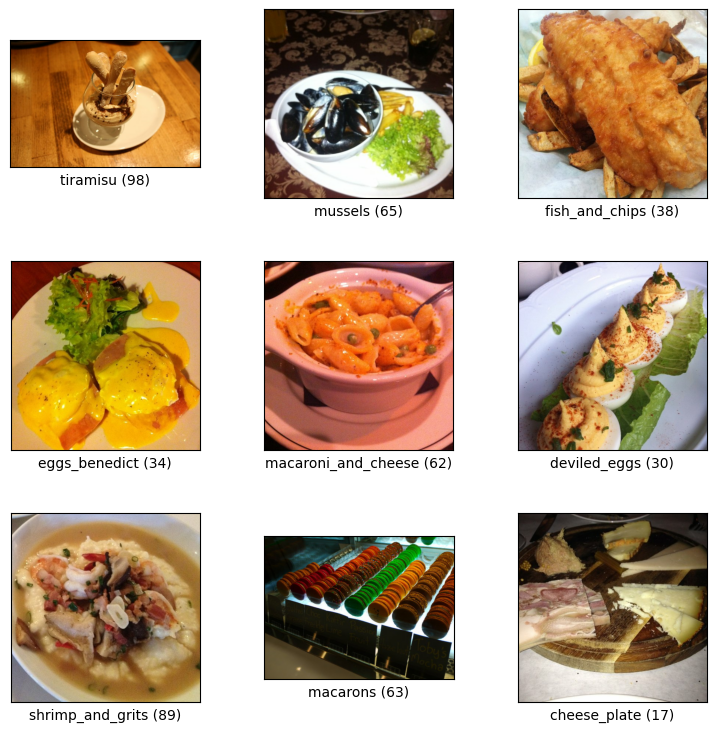

In [9]:
fig = tfds.show_examples(train_ds, ds_info)



```
WE WILL NOW USE CNN TO TRAIN OUR MODEL ON ONLY ONE OF THESE FOOD DISHES AND
THEN RECOGNIZE WHETHER IT PASSES OR NOT
lets choose:
chocolate_cake label:21
```





*   Resizing the Image to 128 x 128
*   Changing into Integer
*   1 means yes 0 means no



In [10]:
len=128
cake=21
train_ds=train_ds.map(
  lambda image, label: (tf.cast(tf.image.resize(image, [len, len]), dtype=tf.int32), tf.cast(label == cake, dtype=tf.int32))
)
valid_ds = valid_ds.map(
    lambda image, label: (tf.cast(tf.image.resize(image, [len,len]), dtype=tf.int32), tf.cast(label == cake, dtype=tf.int32))
)

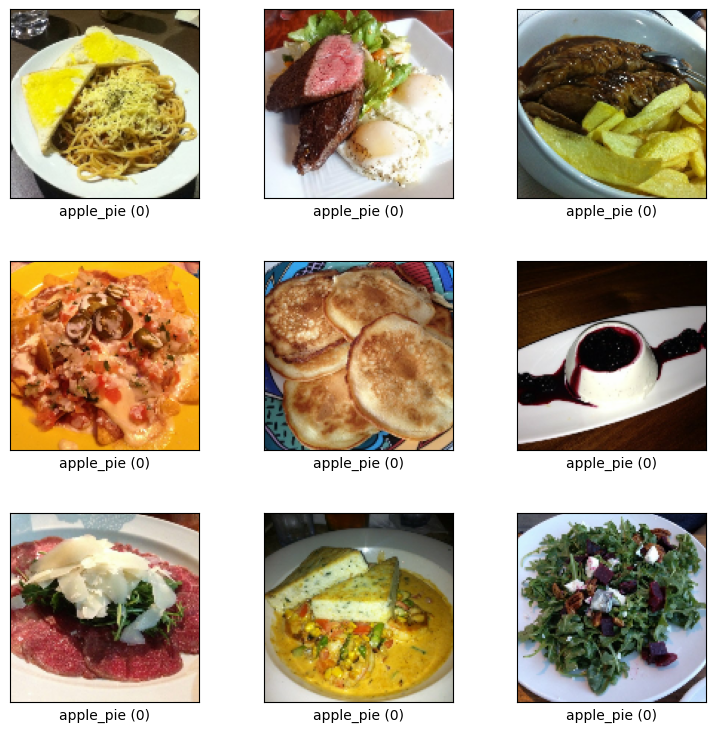

In [11]:
fig = tfds.show_examples(train_ds, ds_info)

Default


```
apple_pie=not cake
baby_back_ribs=cake
```



In [12]:
train_hd_size, valid_hd_size = 750, 250
train_cake = train_ds.filter(lambda _, label: label == 1).repeat(3)
train_notcake = train_ds.filter(lambda _, label: label == 0)

In [13]:
valid_cake = valid_ds.filter(lambda _, label: label == 1).repeat(3)
valid_notcake = valid_ds.filter(lambda _, label: label == 0)

In [14]:
valid_cake

<_RepeatDataset element_spec=(TensorSpec(shape=(128, 128, 3), dtype=tf.int32, name=None), TensorSpec(shape=(), dtype=tf.int32, name=None))>

In [15]:
batch_size = 16
train_ds = tf.data.Dataset.sample_from_datasets([train_cake, train_cake], weights=[0.5, 0.5], stop_on_empty_dataset=True)
train_ds = train_ds.cache().batch(batch_size).prefetch(tf.data.AUTOTUNE)

valid_ds = tf.data.Dataset.sample_from_datasets([valid_cake, valid_cake], weights=[0.5, 0.5], stop_on_empty_dataset=True)
valid_ds = valid_ds.cache().batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [16]:
for image, label in train_ds.take(3):
  print(image[0][0][0])
  print(label)

tf.Tensor([17 15 16], shape=(3,), dtype=int32)
tf.Tensor([1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1], shape=(16,), dtype=int32)
tf.Tensor([249 239 171], shape=(3,), dtype=int32)
tf.Tensor([1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1], shape=(16,), dtype=int32)
tf.Tensor([201 203 191], shape=(3,), dtype=int32)
tf.Tensor([1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1], shape=(16,), dtype=int32)


# **NN Implementation**

In [17]:
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip('horizontal'),
  tf.keras.layers.RandomRotation(0.2),
])

In [18]:
random.seed(0)
model = models.Sequential()
model.add(layers.Rescaling(1./255))
model.add(layers.Conv2D(128, (3, 3), activation='relu', input_shape=(len, len, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Dropout(0.25))
model.add(layers.Conv2D(64, (3, 3), activation='relu', kernel_regularizer=tf.keras.regularizers.l2(l2=0.01)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Dropout(0.25))
model.add(layers.Conv2D(32, (3, 3), activation='relu', kernel_regularizer=tf.keras.regularizers.l2(l2=0.01)))
model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.25))
model.add(layers.Dense(1))
lr=0.01

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
              metrics=['accuracy'])

epochs=1
history = model.fit(
  train_ds,
  validation_data=valid_ds,
  epochs=epochs,
  verbose=1
)

    278/Unknown 580s 2s/step - accuracy: 0.9777 - loss: 0.3599

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


278/278 ━━━━━━━━━━━━━━━━━━━━ 762s 3s/step - accuracy: 0.9777 - loss: 0.3590 - val_accuracy: 1.0000 - val_loss: 2.1570e-04


In [20]:
plt.figure(figsize=(10, 10))
for image_batch, label_batch in valid_ds.take(1):
  images = image_batch
  labels = label_batch

<Figure size 1000x1000 with 0 Axes>

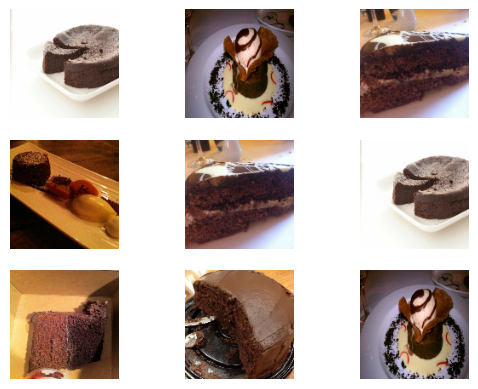

In [21]:
for i in range(9):
  ax = plt.subplot(3, 3, i+1)
  plt.imshow(images[i])
  plt.axis("off")

In [22]:
labels[:9]

<tf.Tensor: shape=(9,), dtype=int32, numpy=array([1, 1, 1, 1, 1, 1, 1, 1, 1], dtype=int32)>

In [23]:
from sklearn.metrics import accuracy_score

In [25]:
predictions = (tf.nn.sigmoid(model.predict(images)) > 0.5).numpy().astype(int)
score = accuracy_score(labels, predictions)
print(score)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
1.0
